# 路线B：CWT 时频图 + 2D-CNN 深度学习

## 概述

本 Notebook 展示**路线B**：用连续小波变换（CWT）把一维信号转成二维时频图（scalogram），
再用卷积神经网络（CNN）像处理图像一样进行手势分类。

### 为什么用这条路线

路线A 用人工设计的特征，而路线B 是**端到端深度学习**：
- 信号处理：CWT 把信号变成彩色"时频图像"，直观展示能量在不同时间、不同频率的分布
- 分类：2D-CNN 自动从时频图中学习判别特征，无需人工设计

CWT scalogram 是论文中展示信号处理最漂亮的配图——一张彩色热力图直观呈现手势的时频结构。

### 核心挑战：小样本

只有 493 个样本，深度学习极易过拟合。本路线采用多种防过拟合手段：
数据增强、Dropout、BatchNorm、权重衰减、早停、标签平滑。

### 整体流程

```
清洗后片段 [T, 3]
    │
    ├─ 每个通道做 CWT → scalogram 时频图
    │     时间轴重采样到 128，尺度轴 64
    │
    ├─ 3 通道堆叠 → [3, 64, 128] 张量（类比 RGB 图像）
    │     全局 log 归一化（保留通道间相对能量）
    │
    └─ 2D-CNN → 10 类手势
```

### 最终结果

| 方法 | Test 准确率 |
|------|------------|
| 基线（9维 + RF） | 0.667 |
| **路线B（CWT + 2D-CNN）** | **0.747** |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.preprocess.io import GESTURE_NAMES
from src.decompose.cwt import cwt_scalogram, cwt_scalogram_3ch, CWT_PARAMS

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

FS = 1000
CH_NAMES = ['CH1', 'CH3', 'CH5']
PROCESSED = PROJECT_ROOT / 'data' / 'processed'

---
## 1. CWT 连续小波变换原理

### 什么是 CWT

CWT（Continuous Wavelet Transform）用一族不同尺度（频率）的小波去"扫描"信号，
得到信号在**时间-频率平面**上的能量分布，称为 scalogram（尺度图）。

简单理解：
- 横轴是**时间**（信号什么时候发生）
- 纵轴是**尺度/频率**（信号包含什么频率成分）
- 颜色深浅是**能量**（该时刻、该频率上信号有多强）

### CWT vs STFT（短时傅里叶变换）

CWT 的优势是**多分辨率**：
- 在低频处用宽窗口 → 频率分辨率高（能分清相近的低频）
- 在高频处用窄窗口 → 时间分辨率高（能定位快速的瞬态）

这对手势这种瞬态信号特别合适。我们用 **Morlet 小波**（时频分析最常用），
64 个尺度，时间轴统一重采样到 128 点。

信号长度: 800 → scalogram: (64, 128) (尺度 x 时间)
尺度对应频率范围: 12.7 ~ 812.5 Hz


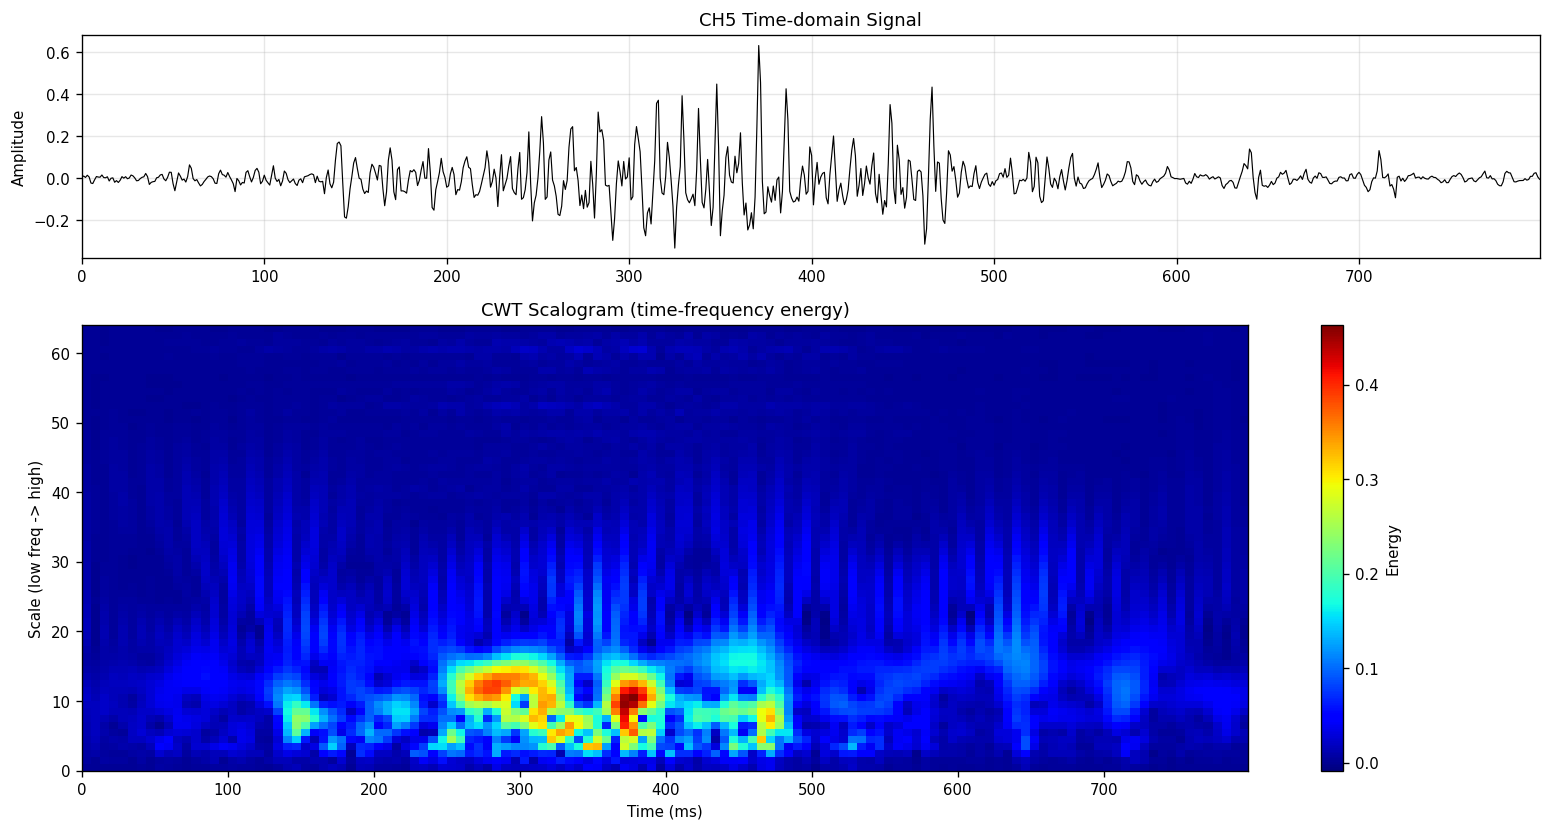

In [2]:
# 加载一个片段，演示单通道 CWT
sample_seg = np.load(sorted((PROCESSED/'segments'/'base').glob('stop-1_*.npy'))[0])
ch = 2  # CH5
signal_1ch = sample_seg[:, ch]

scalogram, freqs = cwt_scalogram(signal_1ch)
print(f'信号长度: {len(signal_1ch)} → scalogram: {scalogram.shape} (尺度 x 时间)')
print(f'尺度对应频率范围: {freqs.min():.1f} ~ {freqs.max():.1f} Hz')

# 上：原信号；下：scalogram
fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={'height_ratios': [1, 2]})
t = np.arange(len(signal_1ch)) / FS * 1000
axes[0].plot(t, signal_1ch, color='black', linewidth=0.7)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'{CH_NAMES[ch]} Time-domain Signal')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, t[-1])

im = axes[1].imshow(scalogram, aspect='auto', cmap='jet', origin='lower',
                    extent=[0, t[-1], 0, scalogram.shape[0]])
axes[1].set_ylabel('Scale (low freq -> high)')
axes[1].set_xlabel('Time (ms)')
axes[1].set_title('CWT Scalogram (time-frequency energy)')
plt.colorbar(im, ax=axes[1], label='Energy')
plt.tight_layout()
plt.show()

### 如何读这张图

- **上图**：CH5 的原始一维信号（时间 vs 幅度）
- **下图**：对应的 scalogram，是一张二维时频能量图
  - 横轴时间，与上图对齐
  - 纵轴尺度（下方低频，上方高频）
  - 颜色越红能量越强，越蓝越弱

可以看到信号能量较强的时刻（上图的尖峰处），在 scalogram 上表现为对应时间位置的亮带。
这张图把"信号在什么时候、什么频率上有能量"一目了然地展示出来——
这正是 CNN 要学习的判别信息。

---
## 2. 三通道 scalogram 堆叠

### 类比 RGB 图像

我们把 3 个通道（CH1/CH3/CH5）的 scalogram 堆叠成一个 [3, 64, 128] 的张量，
就像彩色图像有 R/G/B 三个通道一样。CNN 可以直接处理这种"三通道图像"。

### 关键细节：全局归一化

一个重要的处理是**全局 log 归一化**而非每通道独立归一化：
- log 压缩：缩小动态范围，让弱信号细节也能显现
- 全局归一化：三通道共用同一个归一化尺度，**保留通道间的相对能量差异**

通道间的相对强弱（哪个通道响应最强）是区分手势的关键信息。
实验证明：全局归一化比每通道独立归一化的 CNN 准确率高约 20 个百分点
（0.55 → 0.75）。这是本路线最重要的一个技术点。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.043889005..1.0].


三通道 scalogram: (3, 64, 128), 范围 [-0.04, 1.00]


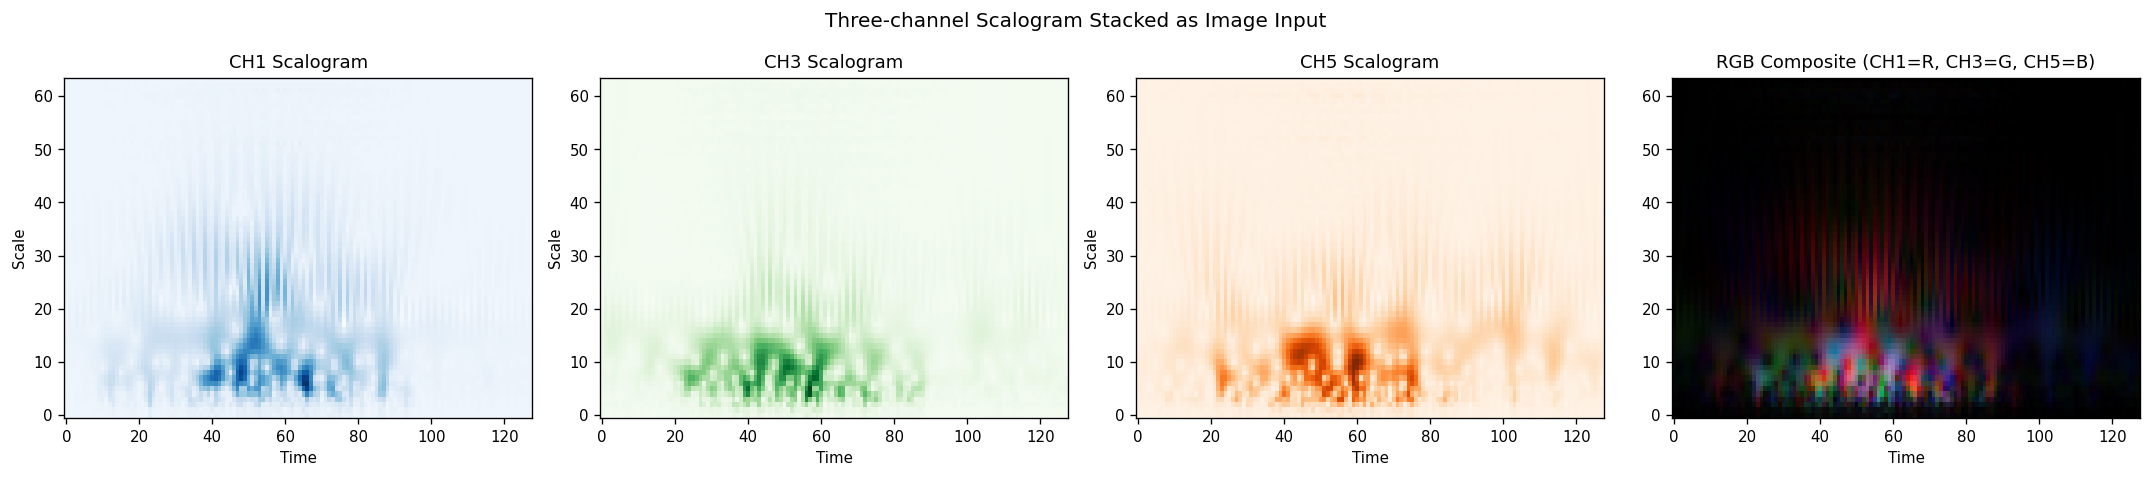

In [3]:
# 生成三通道 scalogram
scal_3ch = cwt_scalogram_3ch(sample_seg)
print(f'三通道 scalogram: {scal_3ch.shape}, 范围 [{scal_3ch.min():.2f}, {scal_3ch.max():.2f}]')

# 分别展示三个通道 + RGB 合成
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
ch_colors_cmap = ['Blues', 'Greens', 'Oranges']
for i in range(3):
    im = axes[i].imshow(scal_3ch[i], aspect='auto', cmap=ch_colors_cmap[i], origin='lower')
    axes[i].set_title(f'{CH_NAMES[i]} Scalogram')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Scale')

# RGB 合成（3通道当成RGB）
rgb = np.transpose(scal_3ch, (1, 2, 0))
axes[3].imshow(rgb, aspect='auto', origin='lower')
axes[3].set_title('RGB Composite (CH1=R, CH3=G, CH5=B)')
axes[3].set_xlabel('Time')

fig.suptitle('Three-channel Scalogram Stacked as Image Input', fontsize=12)
plt.tight_layout()
plt.show()

### 如何读这张图

- **前三张**：CH1/CH3/CH5 各自的 scalogram，用不同颜色表示
- **最右**：把三通道当作 RGB 合成的彩色图

RGB 合成图最能体现通道间差异：某个区域偏红说明 CH1 主导，偏绿说明 CH3 主导，偏蓝说明 CH5 主导。
不同手势会形成不同的"色彩纹理"，这就是 CNN 用来分类的视觉特征。

### 不同手势的 scalogram 对比

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.049265765..0.99999994].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.049872354..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.008242065..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.043889005..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1093232..1.0].


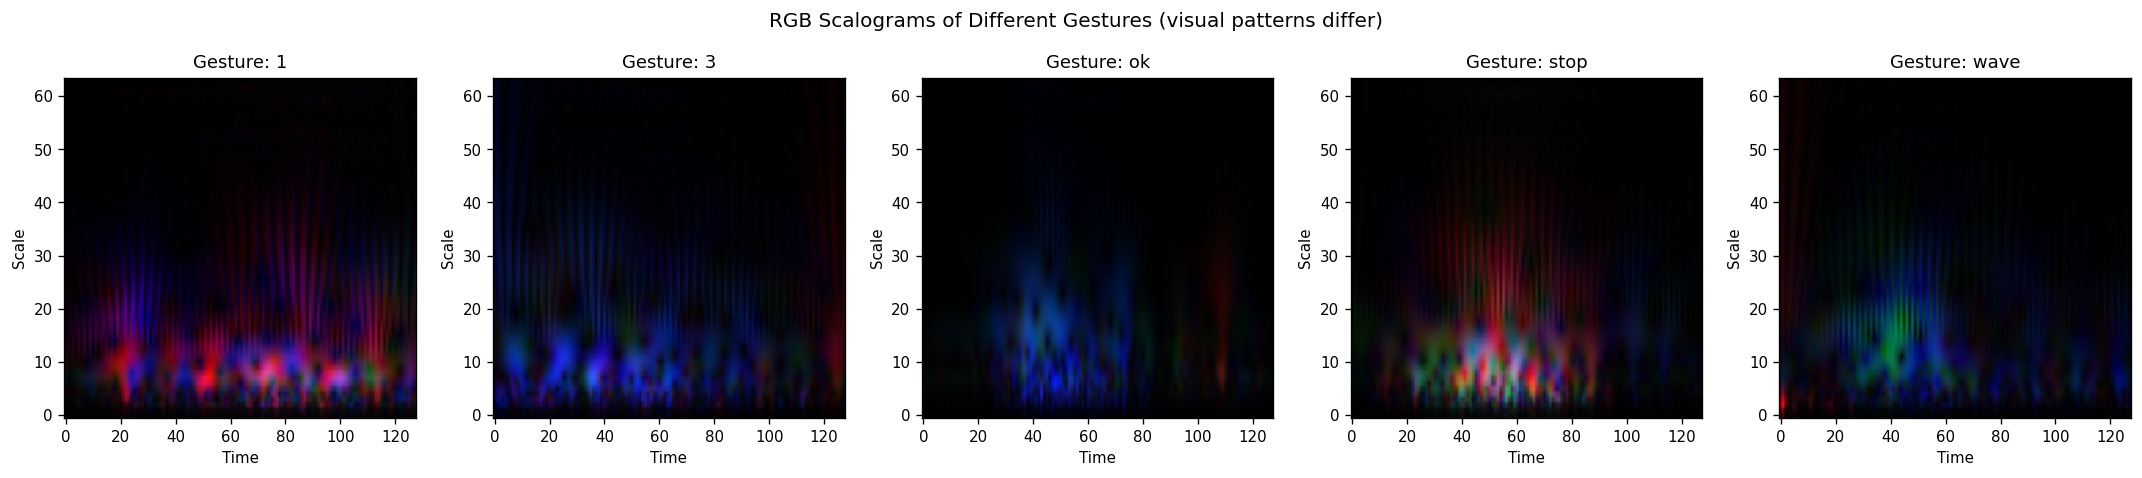

In [4]:
# 对比几个手势的 RGB scalogram
gestures_to_show = ['1', '3', 'ok', 'stop', 'wave']
fig, axes = plt.subplots(1, len(gestures_to_show), figsize=(18, 4))

for ax, gesture in zip(axes, gestures_to_show):
    # 找该手势的一个片段
    matches = sorted((PROCESSED/'segments'/'base').glob(f'{gesture}-1_*.npy'))
    if matches:
        seg = np.load(matches[0])
        scal = cwt_scalogram_3ch(seg)
        rgb = np.transpose(scal, (1, 2, 0))
        ax.imshow(rgb, aspect='auto', origin='lower')
        ax.set_title(f'Gesture: {gesture}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Scale')

fig.suptitle('RGB Scalograms of Different Gestures (visual patterns differ)', fontsize=12)
plt.tight_layout()
plt.show()

### 如何读这张图

5 种不同手势的 RGB scalogram。仔细观察可以发现它们的"色彩纹理"明显不同：
- 能量集中的时间位置不同（有的早、有的晚、有的多峰）
- 主导通道不同（颜色倾向不同）
- 频率分布不同（亮带在高处还是低处）

这些视觉差异就是 CNN 能够区分手势的依据。一张这样的对比图非常适合放进论文，
直观说明"不同手势的时频特征是可区分的"。

---
## 3. 数据增强

### 为什么需要增强

493 个样本对深度学习来说太少，模型容易死记硬背训练样本（过拟合）。
数据增强通过对训练样本做随机变换，相当于"扩充"了训练数据，迫使模型学习更鲁棒的特征。

### 增强手段

| 增强 | 作用 |
|------|------|
| 时间平移 | 模拟动作发生时刻的微小偏移 |
| 幅度缩放 | 模拟信号强度的波动 |
| 高斯噪声 | 提升对噪声的鲁棒性 |
| 频带遮挡(SpecAugment) | 随机遮住一个频带，迫使模型不依赖单一频率 |

注意：增强强度经过调校——太强会导致欠拟合（模型连训练集都学不会）。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.049265765..0.99999994].


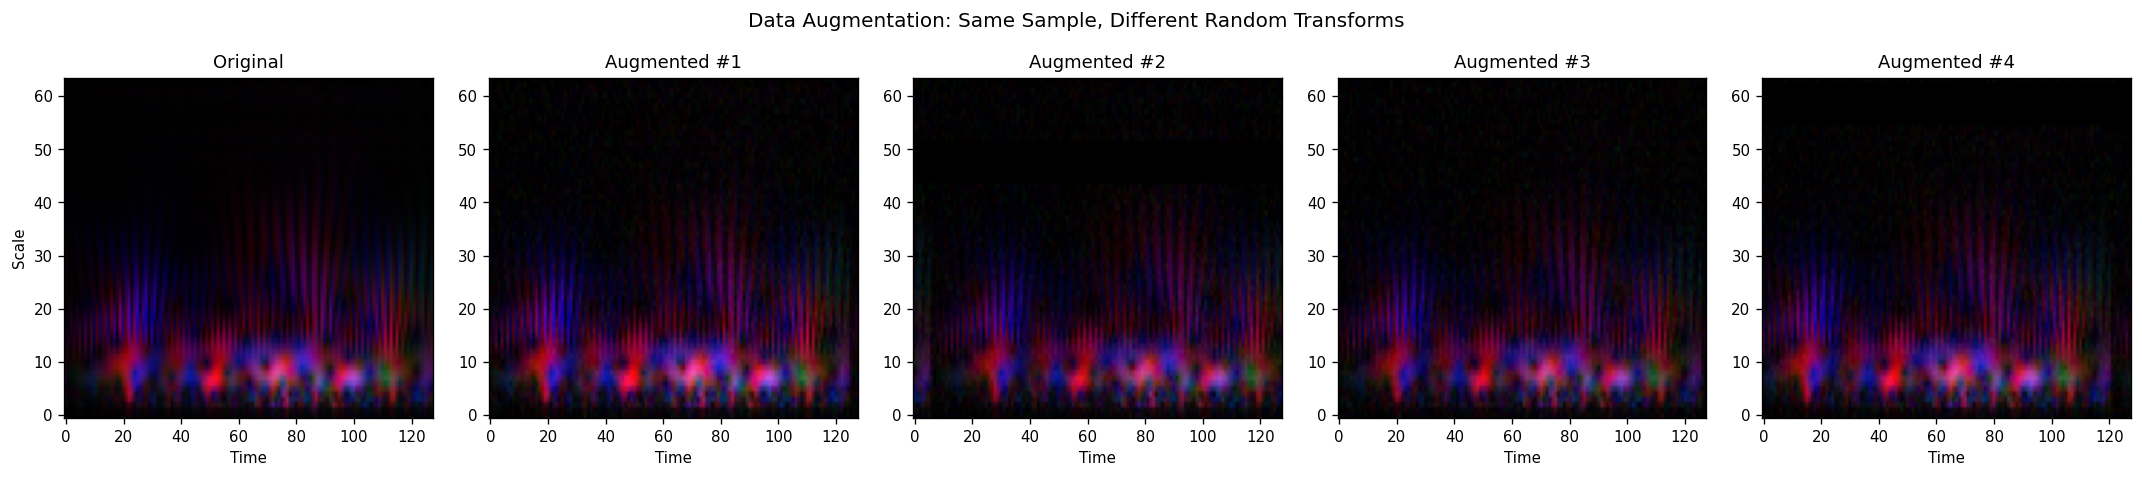

In [5]:
from src.routeB.dataset_b import ScalogramDataset

# 演示增强效果：同一个样本增强多次
idx_df = pd.read_csv(PROCESSED / 'scalograms' / 'scalogram_index.csv')
sample_row = idx_df.iloc[0:1]
ds_aug = ScalogramDataset(sample_row, augment=True)
ds_orig = ScalogramDataset(sample_row, augment=False)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
# 原图
orig, _ = ds_orig[0]
axes[0].imshow(np.transpose(orig.numpy(), (1,2,0)), aspect='auto', origin='lower')
axes[0].set_title('Original')
axes[0].set_xlabel('Time'); axes[0].set_ylabel('Scale')

# 4 个增强版本
np.random.seed(1)
for i in range(1, 5):
    aug, _ = ds_aug[0]
    axes[i].imshow(np.transpose(aug.numpy(), (1,2,0)), aspect='auto', origin='lower')
    axes[i].set_title(f'Augmented #{i}')
    axes[i].set_xlabel('Time')

fig.suptitle('Data Augmentation: Same Sample, Different Random Transforms', fontsize=12)
plt.tight_layout()
plt.show()

### 如何读这张图

最左是原始 scalogram，右边 4 张是对它做随机增强的结果。
可以看到每张都略有不同——时间上有平移、亮度有变化、有的被遮挡了一条横带（频带遮挡）。

每个训练 epoch，模型看到的都是这些随机变化的版本，
相当于训练数据被"放大"了很多倍，从而减轻过拟合。

---
## 4. CNN 模型架构

### 网络结构

```
输入 [3, 64, 128]
    │
    ├─ Conv块1: Conv(3→32) + BN + ReLU + MaxPool  → [32, 32, 64]
    ├─ Conv块2: Conv(32→64) + BN + ReLU + MaxPool → [64, 16, 32]
    ├─ Conv块3: Conv(64→128) + BN + ReLU + MaxPool→ [128, 8, 16]
    ├─ Conv块4: Conv(128→128) + BN + ReLU + MaxPool→[128, 4, 8]
    │
    ├─ 全局平均池化 → [128]
    ├─ Dropout(0.4) + FC(128→128) + ReLU
    ├─ Dropout(0.4) + FC(128→10)
    └─ 输出 10 类
```

### 防过拟合设计

- **BatchNorm**：稳定训练，有轻微正则作用
- **全局平均池化**：代替大全连接层，大幅减少参数（防过拟合关键）
- **Dropout(0.4)**：训练时随机丢弃神经元
- **权重衰减 + 标签平滑 + 早停**：多重正则

In [6]:
from src.routeB.model_b import LightCNN

model = LightCNN()
n_params = sum(p.numel() for p in model.parameters())
print(f'模型总参数: {n_params:,}')
print(f'\n网络结构:')
print(model)

模型总参数: 259,338

网络结构:
LightCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

---
## 5. 训练过程

加载训练好的模型，展示训练曲线。训练采用 Adam 优化器、余弦退火学习率、早停策略。

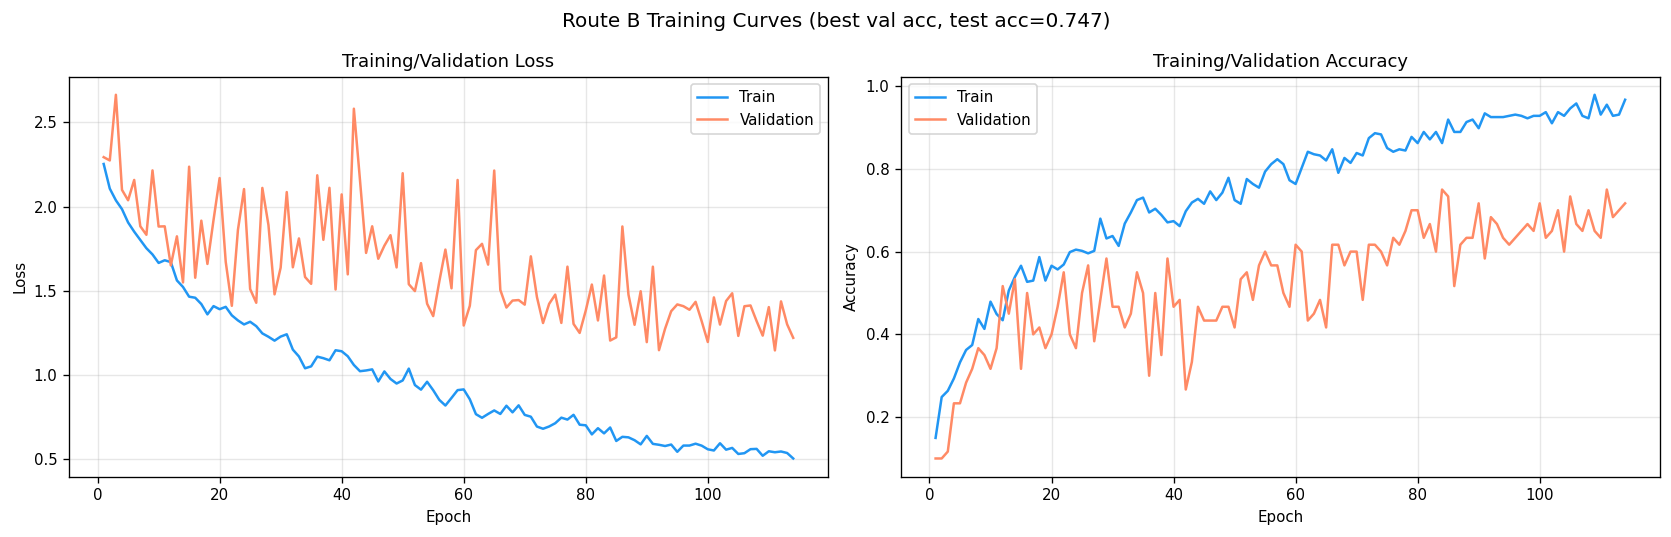

In [7]:
ckpt = torch.load(PROJECT_ROOT / 'checkpoints' / 'routeB_cnn.pt', map_location='cpu', weights_only=False)
h = ckpt['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
epochs = range(1, len(h['train_loss']) + 1)

axes[0].plot(epochs, h['train_loss'], label='Train', color='#2196F3')
axes[0].plot(epochs, h['val_loss'], label='Validation', color='#FF8A65')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training/Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, h['train_acc'], label='Train', color='#2196F3')
axes[1].plot(epochs, h['val_acc'], label='Validation', color='#FF8A65')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training/Validation Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Route B Training Curves (best val acc, test acc={ckpt["test_acc"]:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

### 如何读这张图

- **左图（Loss）**：训练损失（蓝）持续下降，验证损失（橙）下降后趋于平稳
- **右图（Accuracy）**：训练准确率（蓝）上升到较高，验证准确率（橙）跟随上升

观察要点：
- 训练和验证曲线之间的**间隙**反映过拟合程度——间隙越小越好
- 验证准确率到达峰值后，早停机制会保存最佳模型，避免继续训练导致过拟合
- 如果训练准确率远高于验证（间隙大），说明仍有过拟合，但数据增强和正则已尽量缓解

---
## 6. 分类结果

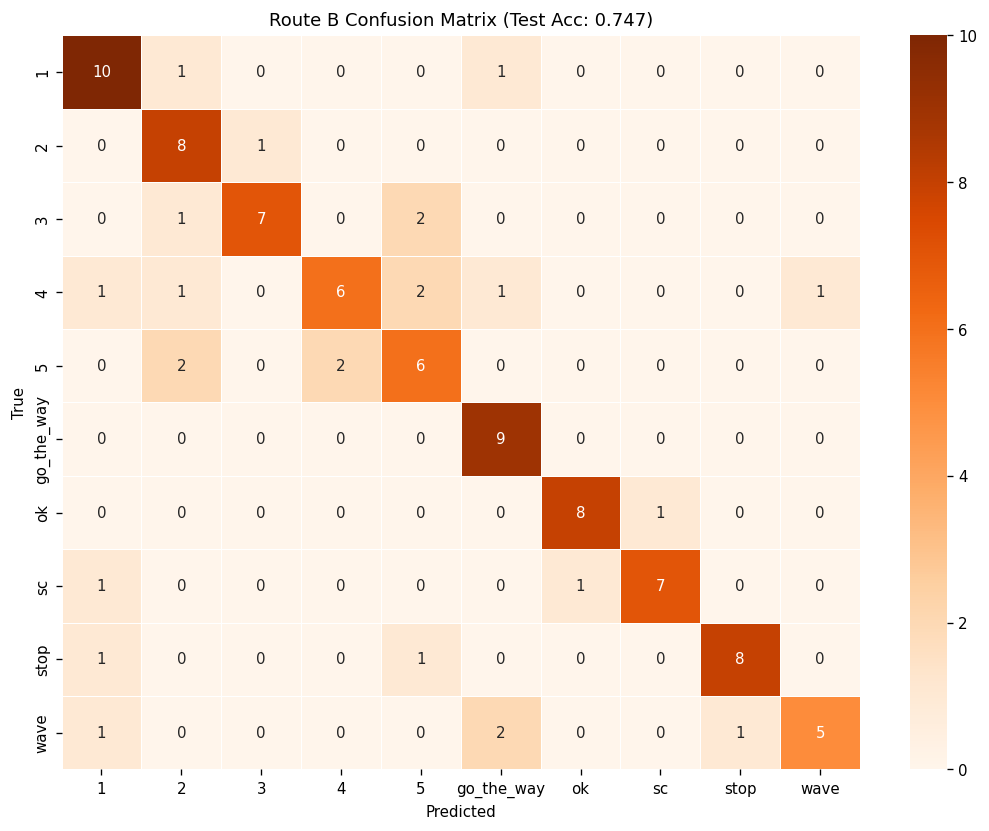

              precision    recall  f1-score   support

           1       0.71      0.83      0.77        12
           2       0.62      0.89      0.73         9
           3       0.88      0.70      0.78        10
           4       0.75      0.50      0.60        12
           5       0.55      0.60      0.57        10
  go_the_way       0.69      1.00      0.82         9
          ok       0.89      0.89      0.89         9
          sc       0.88      0.78      0.82         9
        stop       0.89      0.80      0.84        10
        wave       0.83      0.56      0.67         9

    accuracy                           0.75        99
   macro avg       0.77      0.75      0.75        99
weighted avg       0.77      0.75      0.74        99



In [8]:
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.load_state_dict(ckpt['model_state_dict'])
model.eval()

split_df = pd.read_csv(PROCESSED / 'scalograms' / 'scalogram_split.csv')
test_df = split_df[split_df['split'] == 'test'].reset_index(drop=True)
test_loader = DataLoader(ScalogramDataset(test_df, augment=False), batch_size=64)

all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in test_loader:
        all_preds.extend(model(X).argmax(1).numpy())
        all_labels.extend(y.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

present = sorted(set(all_labels) | set(all_preds))
names = [GESTURE_NAMES[i] for i in present]

cm = confusion_matrix(all_labels, all_preds, labels=present)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=names, yticklabels=names, ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Route B Confusion Matrix (Test Acc: {accuracy_score(all_labels, all_preds):.3f})')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, labels=present, target_names=names))

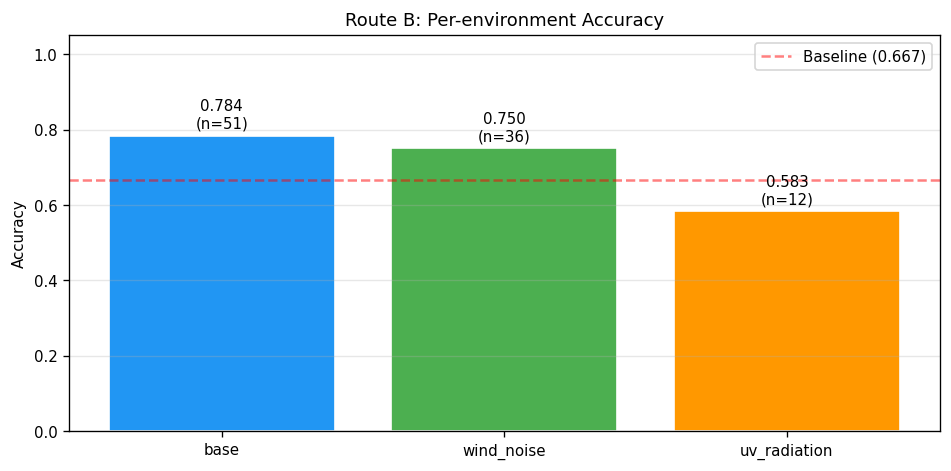

In [9]:
# 各环境准确率
test_df['pred'] = all_preds
envs = ['base', 'wind_noise', 'uv_radiation']
env_accs = [accuracy_score(test_df[test_df.env==e]['label'], test_df[test_df.env==e]['pred']) for e in envs]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(envs, env_accs, color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='white')
for bar, acc, env in zip(bars, env_accs, envs):
    n = len(test_df[test_df.env==env])
    ax.text(bar.get_x()+bar.get_width()/2, acc+0.02, f'{acc:.3f}\n(n={n})', ha='center', fontsize=9)
ax.axhline(0.667, color='red', linestyle='--', alpha=0.5, label='Baseline (0.667)')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('Route B: Per-environment Accuracy')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 如何读这张图

三个环境的测试准确率，红线是基线。关注模型在不同噪声条件下的稳定性，
以及是否都超过了基线水平。

---
## 7. 三方对比

把基线、路线A、路线B 放在一起对比。

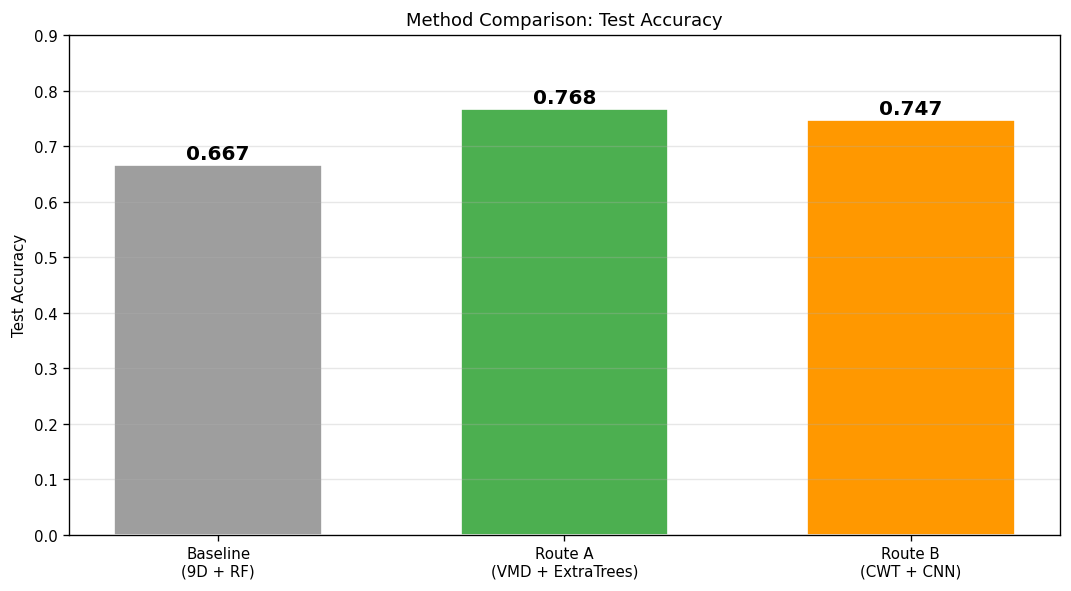

对比总结:
  基线（9维+RF）:          0.667
  路线A（VMD+ExtraTrees）:  0.768  (+10.1%)
  路线B（CWT+CNN）:         0.747  (+8.0%)


In [10]:
# 三方对比
methods = ['Baseline\n(9D + RF)', 'Route A\n(VMD + ExtraTrees)', 'Route B\n(CWT + CNN)']
test_accs = [0.667, 0.768, accuracy_score(all_labels, all_preds)]
colors = ['#9E9E9E', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(methods, test_accs, color=colors, edgecolor='white', width=0.6)
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x()+bar.get_width()/2, acc+0.01, f'{acc:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0, 0.9)
ax.set_title('Method Comparison: Test Accuracy')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('对比总结:')
print(f'  基线（9维+RF）:          0.667')
print(f'  路线A（VMD+ExtraTrees）:  0.768  (+10.1%)')
print(f'  路线B（CWT+CNN）:         {test_accs[2]:.3f}  (+{(test_accs[2]-0.667)*100:.1f}%)')

### 如何读这张图

三种方法的 test 准确率对比。两条新路线都明显超过基线。

### 路线A vs 路线B 怎么选

| 维度 | 路线A（VMD+ExtraTrees） | 路线B（CWT+CNN） |
|------|------------------------|------------------|
| Test 准确率 | 0.768（略高） | 0.747 |
| 训练速度 | 秒级（CPU） | 分钟级（需GPU/MPS） |
| 可解释性 | 强（特征重要度） | 弱（黑盒） |
| 论文配图 | VMD 分解图 | scalogram 时频图（更漂亮） |
| 小样本鲁棒性 | 更好 | 需大量正则 |

---
## 8. 总结

### 路线B 成果

| 指标 | 值 |
|------|-----|
| 信号处理方法 | CWT 连续小波变换（Morlet） |
| 输入 | [3, 64, 128] scalogram（全局 log 归一化） |
| 分类模型 | 轻量 2D-CNN（~26 万参数） |
| **Test 准确率** | **0.747**（基线 0.667，提升 +8.0%） |

### 关键技术点

1. **全局 log 归一化**：保留通道间相对能量，是 CNN 成功的关键（+20% 提升）
2. **数据增强**：缓解小样本过拟合，强度需精心调校
3. **轻量网络 + 强正则**：在 493 样本下避免严重过拟合

### 论文配图建议

- CWT scalogram 时频图（第 1-2 节）：信号处理最直观的展示
- 不同手势 scalogram 对比（第 2 节）：说明可区分性
- 训练曲线（第 5 节）：展示训练过程和泛化能力